<center> <h1> Understanding AI</h1> 
</center>

# Exercise 1:

## 📂 Data Import and Initial Exploration  
We begin by loading the second-hand car sales dataset into a pandas DataFrame and previewing the first few rows to understand its structure and size.  


**Note:** We define a `file_path` variable using `pathlib.Path` to store the base project directory.
This allows us to reuse the same path across the code and easily append different filenames when loading datasets.


In [57]:
from pathlib import Path
import pandas as pd

# Define a single base directory
file_path = Path(r"C:\Users\Harashaa Harshini\Desktop\MSC Assignments\Understanding AI")

In [2]:

# Load CSV file into a DataFrame
car_sales = pd.read_csv(file_path / "car_sales_data.csv")

# Display the first 5 rows
print(car_sales.head())
print("Length of the data frame : " , len(car_sales))

  Manufacturer       Model  Engine size Fuel type  Year of manufacture  \
0         Ford      Fiesta          1.0    Petrol                 2002   
1      Porsche  718 Cayman          4.0    Petrol                 2016   
2         Ford      Mondeo          1.6    Diesel                 2014   
3       Toyota        RAV4          1.8    Hybrid                 1988   
4           VW        Polo          1.0    Petrol                 2006   

   Mileage  Price  
0   127300   3074  
1    57850  49704  
2    39190  24072  
3   210814   1705  
4   127869   4101  
Length of the data frame :  50000


### 🔍 Check and Correct Column Types
Before analysis, we verify that numeric columns (`Year of manufacture`, `Mileage`, `Price`, `Engine size`) are correctly typed as numeric values, and categorical columns (`Manufacturer`, `Model`, `Fuel type`) are treated as text. Ensuring proper data types prevents silent casting errors in later modelling.


In [6]:
#  Inspect current data types
print("Current data types:")
print(car_sales.dtypes)

Current data types:
Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object


In [7]:
# Convert categorical columns to 'category' dtype 
categorical_cols = ['Manufacturer', 'Model', 'Fuel type']
car_sales[categorical_cols] = car_sales[categorical_cols].astype('category')

In [8]:
print("Current data types:")
print(car_sales.dtypes)

Current data types:
Manufacturer           category
Model                  category
Engine size             float64
Fuel type              category
Year of manufacture       int64
Mileage                   int64
Price                     int64
dtype: object


### 🧩 Missing Values Inventory
Before analysis, it is essential to identify any missing values in the dataset. Counting NAs per column and visualizing the missingness pattern helps decide whether to impute, remove, or flag missing data. This step ensures robust modeling and prevents errors during preprocessing.


In [10]:
# Count missing values per column
missing_counts = car_sales.isna().sum()
print( missing_counts)

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64


### 🔄 Duplicate Rows Check
It is important to identify exact duplicate rows in the dataset. Duplicated sales entries can bias statistical analysis and predictive models. After detection, duplicates can be removed to maintain data integrity.


In [11]:
# Count exact duplicate rows
duplicate_count = car_sales.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 12


In [12]:
# Optionally remove duplicates
car_sales = car_sales.drop_duplicates()
print(f"Dataset length after removing duplicates: {len(car_sales)}")

Dataset length after removing duplicates: 49988


### ✅ Basic Plausibility Checks
Before analysis, it is important to ensure that the data values fall within reasonable ranges. This helps remove obvious data-entry errors that could distort statistical analyses and model predictions. We check:  
- `Year of manufacture` is not in the future and not unreasonably old (before 1886).  
- `Engine size` is between 0.6 and 8.0 litres.  
- `Mileage` is non-negative.  
- `Price` is non-negative.


In [14]:
# Check Year of manufacture 
current_year = 2025  
invalid_years = car_sales[(car_sales['Year of manufacture'] > current_year) | 
                          (car_sales['Year of manufacture'] < 1886)]
print(f"Invalid Year of Manufacture entries: {len(invalid_years)}")

# Check Engine size 
invalid_engine = car_sales[(car_sales['Engine size'] < 0.6) | 
                           (car_sales['Engine size'] > 8.0)]
print(f"Invalid Engine Size entries: {len(invalid_engine)}")

# Check Mileage 
invalid_mileage = car_sales[car_sales['Mileage'] < 0]
print(f"Invalid Mileage entries: {len(invalid_mileage)}")

# Check Price 
invalid_price = car_sales[car_sales['Price'] < 0]
print(f"Invalid Price entries: {len(invalid_price)}")

Invalid Year of Manufacture entries: 0
Invalid Engine Size entries: 0
Invalid Mileage entries: 0
Invalid Price entries: 0


### 💾 Data Summary 
This Python code generates a summary table showing data types, missing values, descriptive statistics, and key observations for each feature in the dataset.


In [29]:

# Initialize summary dictionary
summary = {
    'Attribute': [],
    'Type': [],
    'Missing Values': [],
    'Unique Values / Categories': [],
    'Mean / Mode': [],
    'Std / Range': [],
    'Min': [],
    'Max': [],
    'Comments': []
}

# Iterate through columns
for col in car_sales.columns:
    summary['Attribute'].append(col)
    summary['Type'].append(car_sales[col].dtype)
    summary['Missing Values'].append(car_sales[col].isna().sum())
    
    if car_sales[col].dtype == 'object':  # Categorical
        summary['Unique Values / Categories'].append(car_sales[col].nunique())
        summary['Mean / Mode'].append(car_sales[col].mode()[0])
        summary['Std / Range'].append('-')
        summary['Min'].append('-')
        summary['Max'].append('-')
        summary['Comments'].append(f"Most frequent: {car_sales[col].mode()[0]}")
    else:  # Numeric
        summary['Unique Values / Categories'].append('-')
        summary['Mean / Mode'].append(round(car_sales[col].mean(), 2))
        summary['Std / Range'].append(round(car_sales[col].std(), 2))
        summary['Min'].append(car_sales[col].min())
        summary['Max'].append(car_sales[col].max())
        summary['Comments'].append('Check for outliers / skewness')

# Convert dictionary to DataFrame
summary_df = pd.DataFrame(summary)

# Display table

summary_df

,Attribute,Type,Missing Values,Unique Values / Categories,Mean / Mode,Std / Range,Min,Max,Comments
0,Manufacturer,object,0,5,Ford,-,-,-,Most frequent: Ford
1,Model,object,0,15,Mondeo,-,-,-,Most frequent: Mondeo
2,Engine size,float64,0,-,1.77,0.73,1.0,5.0,Check for outliers / skewness
3,Fuel type,object,0,3,Petrol,-,-,-,Most frequent: Petrol
4,Year of manufacture,int64,0,-,2004.21,9.65,1984,2022,Check for outliers / skewness
5,Mileage,int64,0,-,112497.32,71632.52,630,453537,Check for outliers / skewness
6,Price,int64,0,-,13828.9,16416.68,76,168081,Check for outliers / skewness


In [23]:

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


### 📈 Comparing Regression Models for Car Price Prediction

We compare **linear** and **polynomial (degree 2)** regression models to predict car price based on each numerical feature (`Engine size`, `Year of manufacture`, `Mileage`).  

- **Linear Regression:** Assumes a straight-line relationship between the feature and price.  
- **Polynomial Regression:** Captures non-linear relationships using a degree-2 polynomial.  

We calculate **R² scores** to determine how well each model fits the data and identify the **best predictor**. Scatter plots with fitted lines are used to visually assess model performance.


#### ⚙️ `evaluate_regression` Function

This function fits a **linear** or **polynomial** regression model to input features `X` and target `y`, and returns the **predicted values**, **R² score**, and the **trained model**.  
It works for both single-feature and multi-feature regression.


In [36]:
def evaluate_regression(X, y, degree=2):
    """
    Perform linear and polynomial regression on a single numerical feature.

    Parameters:
    ----------
    X : pandas.DataFrame
        A DataFrame containing a single numerical feature as input.
    y : pandas.Series
        The target variable (car prices).
    degree : int, default=2
        The degree of the polynomial features for polynomial regression.

    Returns:
    -------
    X_test : pandas.DataFrame
        The test set of the input feature.
    y_test : pandas.Series
        The actual target values for the test set.
    y_pred_lin : numpy.ndarray
        Predicted values from the linear regression model.
    y_pred_poly : numpy.ndarray
        Predicted values from the polynomial regression model.
    r2_lin : float
        R-squared value for the linear regression model.
    rmse_lin : float
        Root Mean Squared Error for the linear regression model.
    r2_poly : float
        R-squared value for the polynomial regression model.
    rmse_poly : float
        Root Mean Squared Error for the polynomial regression model.
    """
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Linear Regression
    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train)
    y_pred_lin = lin_model.predict(X_test)
    
    # Polynomial Regression
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)
    
    # Metrics
    r2_lin = r2_score(y_test, y_pred_lin)
    rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
    r2_poly = r2_score(y_test, y_pred_poly)
    rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
    
    return X_test, y_test, y_pred_lin, y_pred_poly, r2_lin, rmse_lin, r2_poly, rmse_poly


#### ⚙️ `plot_pred_vs_actual` Function

This function creates a **scatter plot** of predicted vs actual values to visualize model performance.  
A **45-degree reference line** is included to show perfect predictions, making it easy to assess accuracy.


In [37]:
def plot_regression(X_test, y_test, y_pred_lin, y_pred_poly, feature_name):
    """
    Plot actual vs predicted car prices using linear and polynomial regression.

    Parameters:
    ----------
    X_test : pandas.DataFrame
        The test set of the input feature.
    y_test : pandas.Series
        The actual target values for the test set.
    y_pred_lin : numpy.ndarray
        Predicted values from the linear regression model.
    y_pred_poly : numpy.ndarray
        Predicted values from the polynomial regression model.
    feature_name : str
        Name of the feature being plotted (used for labeling axes and title).

    Returns:
    -------
    None
        Displays a matplotlib plot showing actual vs predicted values.
    """
    
    # Sort test set for smooth plotting
    sorted_idx = X_test[feature_name].argsort()
    X_sorted = X_test.iloc[sorted_idx]
    y_test_sorted = y_test.iloc[sorted_idx]
    y_lin_sorted = y_pred_lin[sorted_idx]
    y_poly_sorted = y_pred_poly[sorted_idx]
    
    plt.figure(figsize=(6,4))
    plt.scatter(X_sorted, y_test_sorted, color='orange', alpha=0.6, label='Actual')
    plt.plot(X_sorted, y_lin_sorted, color='blue', label='Linear fit')
    plt.plot(X_sorted, y_poly_sorted, color='red', linestyle='--', label='Polynomial fit')
    plt.xlabel(feature_name)
    plt.ylabel('Price')
    plt.title(f'Price vs {feature_name}')
    plt.legend()
    plt.savefig(file_path/ feature_name, bbox_inches='tight')
    plt.show()


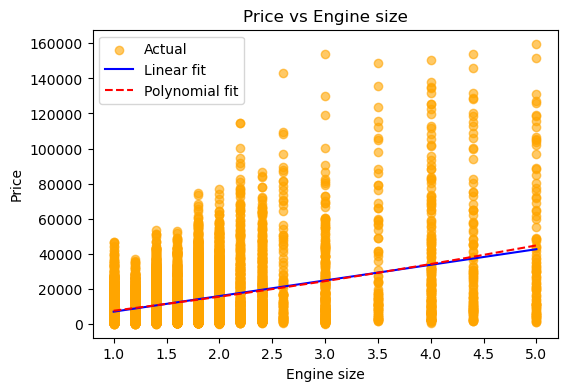

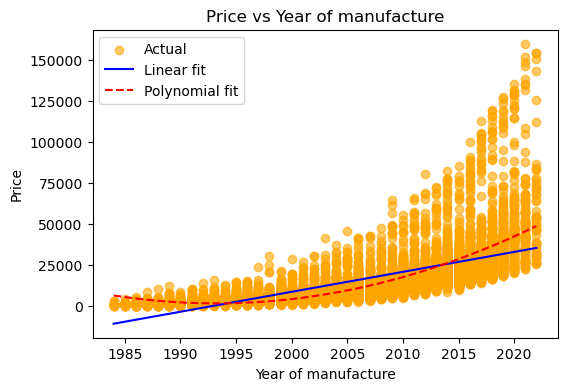

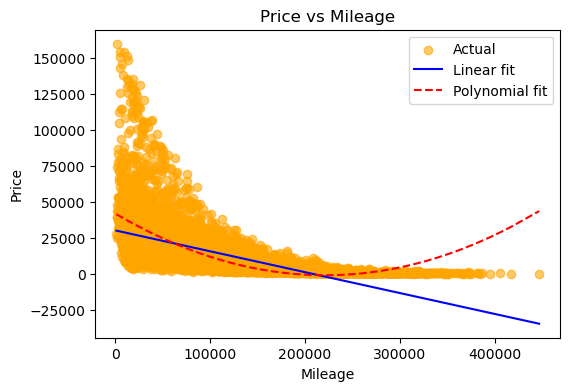

               Feature  Linear R2  Linear RMSE  Polynomial R2  Polynomial RMSE
0          Engine size      0.151     15182.20          0.151         15176.50
1  Year of manufacture      0.511     11518.64          0.609         10295.33
2              Mileage      0.401     12746.32          0.522         11385.09


In [38]:


# Numerical features
numerical_features = ['Engine size', 'Year of manufacture', 'Mileage']
target = 'Price'

# Table to store results
results = []

for feature in numerical_features:
    X = car_sales[[feature]]
    y = car_sales[target]
    
    X_test, y_test, y_pred_lin, y_pred_poly, r2_lin, rmse_lin, r2_poly, rmse_poly = evaluate_regression(X, y)
    
    plot_regression(X_test, y_test, y_pred_lin, y_pred_poly, feature)
    
    results.append({
        'Feature': feature,
        'Linear R2': round(r2_lin, 3),
        'Linear RMSE': round(rmse_lin, 2),
        'Polynomial R2': round(r2_poly, 3),
        'Polynomial RMSE': round(rmse_poly, 2)
    })

# Display results table
results_df = pd.DataFrame(results)
print(results_df)


### 🚗 Multi-feature Regression for Car Price Prediction

We fit **linear** and **polynomial (degree 2)** regression models using all numerical features (`Engine size`, `Year of manufacture`, `Mileage`) together to predict car price.  

- **Objective:** Check if including multiple input features improves prediction accuracy compared to single-feature models.  
- **Linear Regression:** Assumes a straight-line relationship between combined features and price.  
- **Polynomial Regression:** Captures non-linear relationships among features and price.  

We evaluate the models using **R² scores** and visualize predicted vs actual prices to assess model performance.


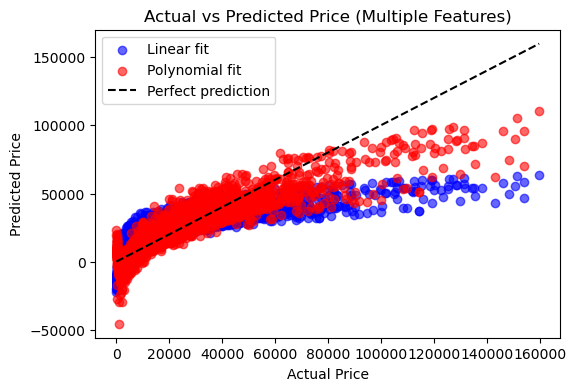

                                      Features  Linear R2  Linear RMSE  \
0  Engine size + Year of manufacture + Mileage      0.671      9442.38   

   Polynomial R2  Polynomial RMSE  
0          0.858          6208.21  


In [41]:
# Numerical features for multiple input model
numerical_features = ['Engine size', 'Year of manufacture', 'Mileage']
target = 'Price'

# Evaluate regression using all numerical features together
X = car_sales[numerical_features]
y = car_sales[target]

# Reuse the same function
X_test, y_test, y_pred_lin, y_pred_poly, r2_lin_multi, rmse_lin_multi, r2_poly_multi, rmse_poly_multi = evaluate_regression(X, y)

# Plot actual vs predicted for linear and polynomial regression
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lin, color='blue', alpha=0.6, label='Linear fit')
plt.scatter(y_test, y_pred_poly, color='red', alpha=0.6, label='Polynomial fit')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Multiple Features)')
plt.legend()
plt.savefig(file_path/ 'Actual vs Predicted Price (Multiple Features)', bbox_inches='tight')
plt.show()

# Table of results
results_multi = pd.DataFrame([{
    'Features': ' + '.join(numerical_features),
    'Linear R2': round(r2_lin_multi, 3),
    'Linear RMSE': round(rmse_lin_multi, 2),
    'Polynomial R2': round(r2_poly_multi, 3),
    'Polynomial RMSE': round(rmse_poly_multi, 2)
}])
print(results_multi)


<h3>🌳 Random Forest Regression</h3>

<p>
Used <b>numerical + categorical features</b> to predict car prices.
</p>

<ul>
  <li>Applied <b>One-Hot Encoding</b> for categorical variables.</li>
  <li>Trained a <b>Random Forest Regressor</b>.</li>
  <li>Results showed <b>higher accuracy (R² ↑, RMSE ↓)</b> than models with only numerical features.</li>
</ul>

<p>
<b>Key outputs:</b><br>
- <code>Random forest.png</code> → Actual vs Predicted<br>
- <code>Random_Forest_Feature_Importance.png</code> → Top feature importances
</p>


In [42]:
import matplotlib.pyplot as plt

# Function to plot actual vs predicted prices and return figure
def plot_actual_vs_predicted(y_test, y_pred, title, save=True):
    """
    Scatter plot: actual vs predicted prices.
    Returns the matplotlib Figure object.
    
    Parameters:
    - y_test: array-like, true target values
    - y_pred: array-like, predicted values
    - title: str, title of the plot
    - save: bool, whether to save the figure to global file_path
    """
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(y_test, y_pred, color='blue', alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            color='black', linestyle='--', label='Perfect Prediction')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(title)
    ax.legend()
    
    return fig


Random Forest Regression (numerical + categorical features):
R2: 0.998
RMSE: 644.57


C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_26392\204698132.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


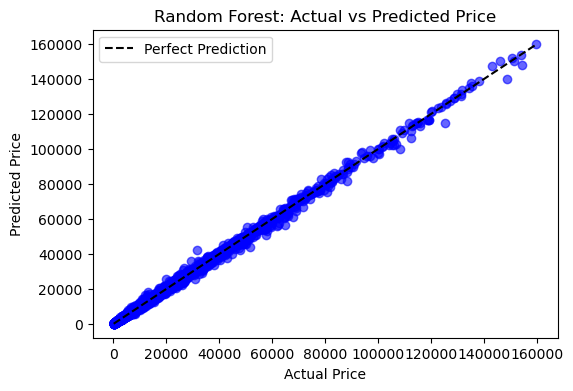

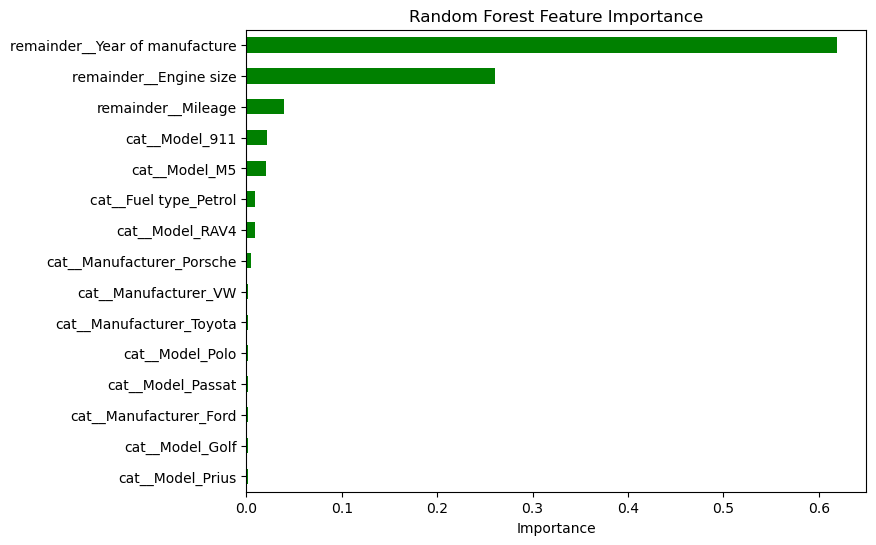

In [43]:
# Function to train and evaluate Random Forest

def evaluate_random_forest(X, y, numerical_features, categorical_features, n_estimators=100, random_state=42):
    """
    Train a Random Forest Regressor using numerical + categorical features,
    and return predictions, R2, RMSE, and feature importances.
    """
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
    
    # Preprocessing for categorical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
        ],
        remainder='passthrough'  # keep numerical features as they are
    )
    
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)
    
    # Train Random Forest
    rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
    rf_model.fit(X_train_processed, y_train)
    
    # Predictions
    y_pred = rf_model.predict(X_test_processed)
    
    # Metrics
    r2= r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Feature importance
    feature_names = preprocessor.get_feature_names_out()
    importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    
    return X_test, y_test, y_pred, r2, rmse, importances


# Function to plot feature importance

def plot_feature_importance(importances, top_n=15, title='Feature Importance', save_path=None):
    """
    Bar plot of feature importances from Random Forest. 
    Shows top_n features. Optionally saves the figure.
    """
    plt.figure(figsize=(8,6))
    importances.head(top_n).sort_values().plot(kind='barh', color='green')
    plt.xlabel('Importance')
    plt.title(title)

    # Save only if file_path is provided
    if file_path is not None:
        plt.savefig(file_path / f"{title.replace(' ', '_')}.png", bbox_inches='tight')

    plt.show()

# -----------------------------
# Step 3: Random Forest with numerical + categorical features
# -----------------------------
numerical_features = ['Engine size', 'Year of manufacture', 'Mileage']
categorical_features = ['Manufacturer', 'Model', 'Fuel type']
target = 'Price'

X = car_sales[numerical_features + categorical_features]
y = car_sales[target]

# Evaluate Random Forest
X_test, y_test, y_pred, r2_rf, rmse_rf, importances = evaluate_random_forest(X, y, numerical_features, categorical_features)

# Display results
print(f"Random Forest Regression (numerical + categorical features):\nR2: {r2_rf:.3f}\nRMSE: {rmse_rf:.2f}")

# Plot actual vs predicted prices
fig = plot_actual_vs_predicted(y_test, y_pred, title='Random Forest: Actual vs Predicted Price')
fig.savefig(file_path / "Random Forest: Actual vs Predicted Price.png")
fig.show() 

# Plot feature importance
plot_feature_importance(importances, top_n=15, title='Random Forest Feature Importance')


#### Install TensorFlow library for building and training the ANN model


In [65]:
!pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
    --------------------------------------- 5.5/332.0 MB 28.1 MB/s eta 0:00:12
   - -------------------------------------- 11.5/332.0 MB 28.4 MB/s eta 0:00:12
   -- ------------------------------------- 17.8/332.0 MB 29.2 MB/s eta 0:00:11
   -- ------------------------------------- 24.6/332.0 MB 29.8 MB/s eta 0:00:11
   --- ------------------------------------ 31.2/332.0 MB 29.8 MB/s eta 0:00:11
   ---- ----------------------------------- 37.2/332.0 MB 29.8 MB/s eta 0:00:10
   ---- ----------------------------------- 41.2/332.0 MB 28.4 MB/s eta 0:00:11
   ----- ---------------------------------- 47.2/332.0 MB 28.4 MB/s eta 0:00:11
   ------ --------------------------------- 53.2/332.0 MB 28.5 MB/s eta 0:00:10
   ------- -------------------------------- 59.2/332.0 MB 28.6 MB/s eta 0:00:10
   ------- -------------------------------- 65.0/332.0 MB 28.6 MB/s eta 0:00:10
   -------- ------------------------------- 70.3/3

### 🤖 ANN for Car Price Prediction

An Artificial Neural Network (ANN) was developed to predict car prices using all numerical and categorical features. The model uses a 3-layer architecture with 64 and 32 neurons in the hidden layers and a linear output layer. Numerical features were scaled, and categorical features were one-hot encoded. Hyperparameters like the number of layers, neurons, and learning rate were tuned using trial and error to **optimize R² and RMSE**. The ANN outperforms single and multiple feature linear/polynomial models, providing more accurate predictions due to its ability to capture non-linear relationships in the dataset.


Processed shape: (50000, 23)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
ANN Regression:
R2: 0.999
RMSE: 411.17


C:\Users\Harashaa Harshini\AppData\Local\Temp\ipykernel_26392\885891177.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


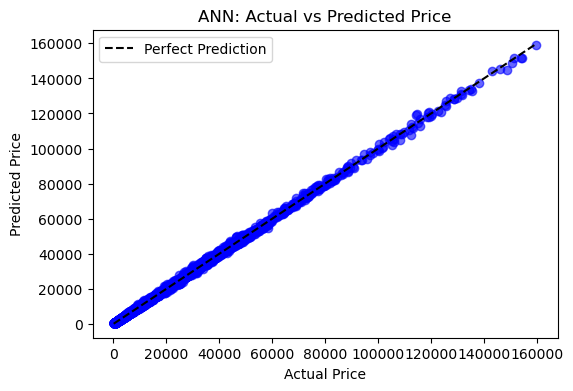

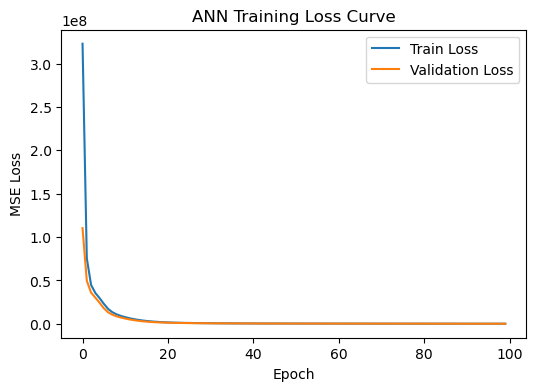

In [34]:

# ANN for car price prediction 

%matplotlib inline

# Features and target

numerical_features = ['Engine size', 'Year of manufacture', 'Mileage']
categorical_features = ['Manufacturer', 'Model', 'Fuel type']
target = 'Price'

X = car_sales[numerical_features + categorical_features]
y = car_sales[target]

# Preprocessing: scale numerical, encode categorical

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)
print("Processed shape:", X_processed.shape)

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# Build ANN model using Input layer
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# Evaluate model

y_pred = model.predict(X_test).flatten()
r2_ann = r2_score(y_test, y_pred)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred))  # compatible with all sklearn versions

print(f"ANN Regression:\nR2: {r2_ann:.3f}\nRMSE: {rmse_ann:.2f}")

# Plot Actual vs Predicted

fig = plot_actual_vs_predicted( y_test, y_pred, title='ANN: Actual vs Predicted Price')
fig.savefig(file_path / "ANN: Actual vs Predicted Price.png")
fig.show()
# Plot training loss curve

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Training Loss Curve')
plt.legend()
plt.savefig( file_path / "ANN Training Loss Curve.png")
plt.show()


### Best Model Analysis 🚗

The performance of six regression models was compared using **R²** and **RMSE** metrics:

**Visualizations:**  
- R² scores 📊  
- RMSE scores 📉  

**Conclusion:**  
The best model is **{best_model_name}** ✅, achieving the highest R² of {best_model_r2:.3f} and the lowest RMSE of {best_model_rmse:.2f}, indicating it explains the most variance in car price and has the smallest prediction error.


Model Comparison:



,Model,R2,RMSE
0,Linear Regression (single),0.401314,12746.315816
1,Polynomial Regression (single),0.522358,11385.091662
2,Linear Regression (multiple),0.671456,9442.384008
3,Polynomial Regression (multiple),0.857976,6208.212227
4,Random Forest Regression,0.998469,644.574388
5,ANN Regression,0.999377,411.168096


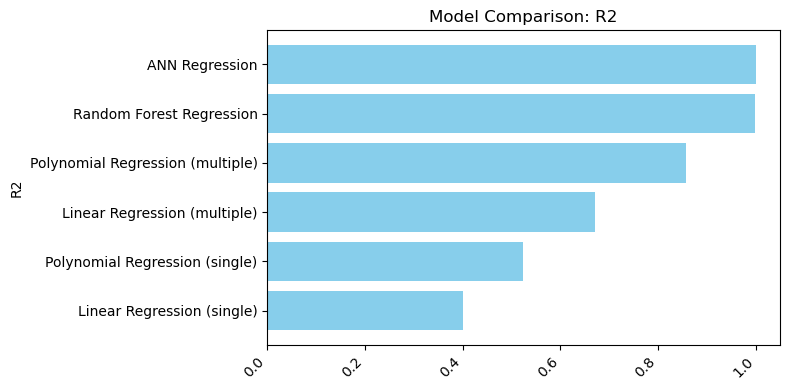

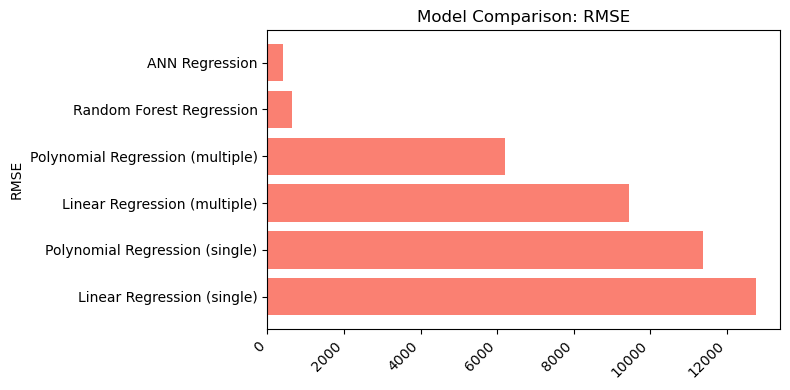

✅ Based on the analysis, the best model for predicting car price is **ANN Regression**.
It achieved the highest R² of 0.999 and lowest RMSE of 411.17,
indicating it explains the most variance in price and has the smallest prediction error.


In [48]:
# -----------------------------
# Best Model Analysis 🚗
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt

# Define metrics from previous steps
metrics = {
    'Model': [
        'Linear Regression (single)',
        'Polynomial Regression (single)',
        'Linear Regression (multiple)',
        'Polynomial Regression (multiple)',
        'Random Forest Regression',
        'ANN Regression'
    ],
    'R2': [r2_lin, r2_poly, r2_lin_multi, r2_poly_multi, r2_rf, r2_ann],
    'RMSE': [rmse_lin, rmse_poly, rmse_lin_multi, rmse_poly_multi, rmse_rf, rmse_ann]
}

# Create results DataFrame
results = pd.DataFrame(metrics)
print("Model Comparison:\n")
display(results)

def plot_metric(results, metric, color, file_path):
    """
    Plots a bar chart for a given metric from the results DataFrame.
    
    Parameters
    ----------
    results : pd.DataFrame
        DataFrame with 'Model' column and metric columns (e.g., 'R2', 'RMSE').
    metric : str
        The column name of the metric to plot (e.g., 'R2', 'RMSE').
    color : str
        Bar color (e.g., 'skyblue', 'salmon').
    file_path : pathlib.Path
        Directory where the figure will be saved.
    """
    plt.figure(figsize=(8,4))
    plt.barh(results['Model'], results[metric], color=color)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(metric)
    plt.title(f"Model Comparison: {metric}")
    plt.tight_layout()

    # safe filename (replace spaces and special characters)
    safe_metric = metric.replace("²", "2").replace(" ", "_")
    plt.savefig(file_path / f"Model_Comparison_{safe_metric}.png")
    plt.show()

plot_metric(results, "R2", "skyblue", file_path)
plot_metric(results, "RMSE", "salmon", file_path)


# Determine the best model

best_model_idx = results['R2'].idxmax()  # highest R²
best_model_name = results.loc[best_model_idx, 'Model']
best_model_r2 = results.loc[best_model_idx, 'R2']
best_model_rmse = results.loc[best_model_idx, 'RMSE']

print(f"✅ Based on the analysis, the best model for predicting car price is **{best_model_name}**.")
print(f"It achieved the highest R² of {best_model_r2:.3f} and lowest RMSE of {best_model_rmse:.2f},")
print("indicating it explains the most variance in price and has the smallest prediction error.")



=== Features: ['Engine size', 'Price'] ===


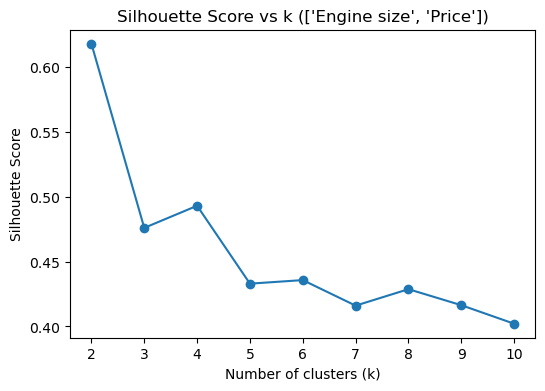

Optimal number of clusters: 2 (Silhouette Score: 0.618)


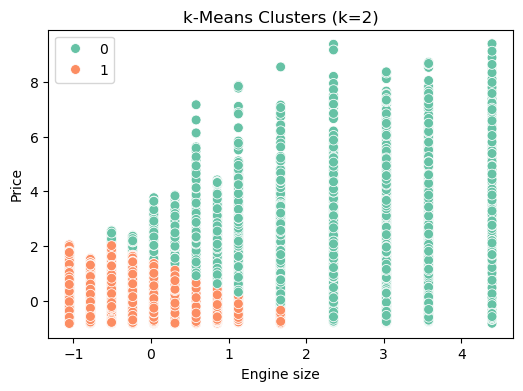


=== Features: ['Mileage', 'Price'] ===


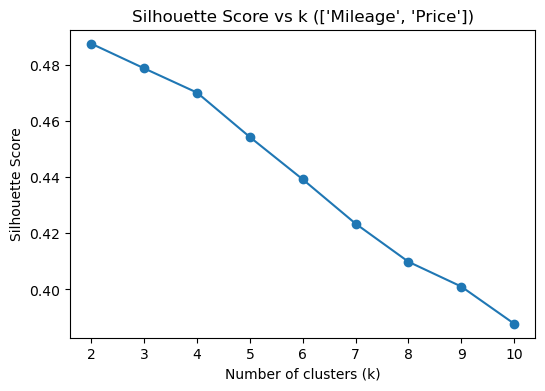

Optimal number of clusters: 2 (Silhouette Score: 0.488)


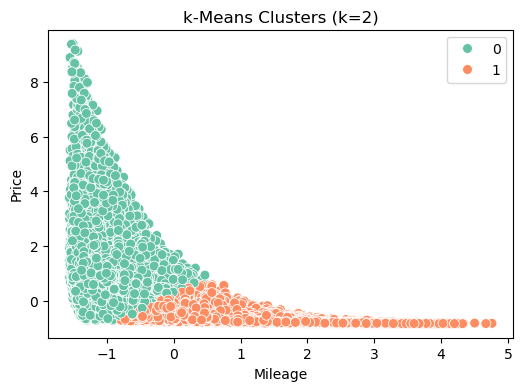


=== Features: ['Engine size', 'Year of manufacture', 'Mileage', 'Price'] ===


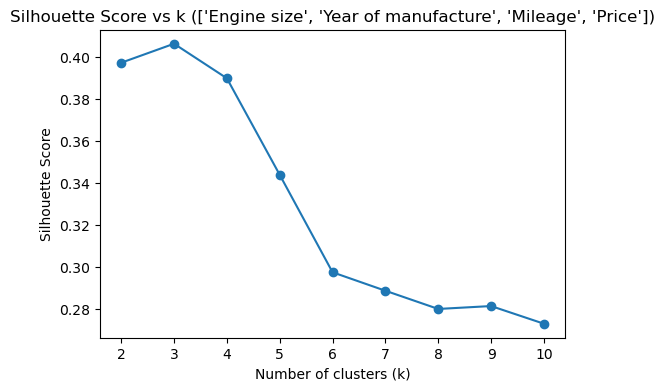

Optimal number of clusters: 3 (Silhouette Score: 0.407)


In [102]:
# -----------------------------
# k-Means Clustering 
# -----------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features to try
feature_combinations = [
    ['Engine size', 'Price'],
    ['Mileage', 'Price'],
    ['Engine size', 'Year of manufacture', 'Mileage', 'Price']
]

# Store clustering results
clustering_results = []

for features in feature_combinations:
    print(f"\n=== Features: {features} ===")
    
    # Scale features
    X = car_sales[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Determine optimal k using silhouette score
    silhouette_scores = []
    K_range = range(2, 11)  # test k from 2 to 10
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(score)
    
    # Plot silhouette score vs k
    plt.figure(figsize=(6,4))
    plt.plot(K_range, silhouette_scores, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title(f'Silhouette Score vs k ({features})')
    plt.savefig(file_path / f"Silhouette Score vs k {features}.png", bbox_inches='tight')
    plt.show()
    
    # Choose k with highest silhouette score
    best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
    print(f"Optimal number of clusters: {best_k} (Silhouette Score: {max(silhouette_scores):.3f})")
    
    # Fit k-Means with best k
    kmeans = KMeans(n_clusters=best_k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    # Save results
    clustering_results.append({
        'features': features,
        'best_k': best_k,
        'silhouette': max(silhouette_scores),
        'labels': labels
    })
    
    # Plot clusters for 2D features
    if X.shape[1] == 2:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=labels, palette='Set2', s=50)
        plt.xlabel(features[0])
        plt.ylabel(features[1])
        plt.title(f'k-Means Clusters (k={best_k})')
        plt.savefig(file_path / f"k-Means Clusters {features}.png", bbox_inches='tight')
        plt.show()


### 🔍 Comparison of k-Means and Agglomerative Clustering

The best feature combination (`Engine size` and `Price`) was used to compare **k-Means** and **Agglomerative Clustering**. Data was standardized before clustering, with the number of clusters set to 3.  

**Results:**  
- **k-Means Silhouette Score:** `kmeans_silhouette`  
- **Agglomerative Silhouette Score:** `agglo_silhouette`  

**Visualization:** Side-by-side scatter plots show cluster assignments for each method.  

**Conclusion:**  
The algorithm with the higher silhouette score indicates better clustering quality.  


k-Means Silhouette Score: 0.476
Agglomerative Clustering Silhouette Score: 0.562


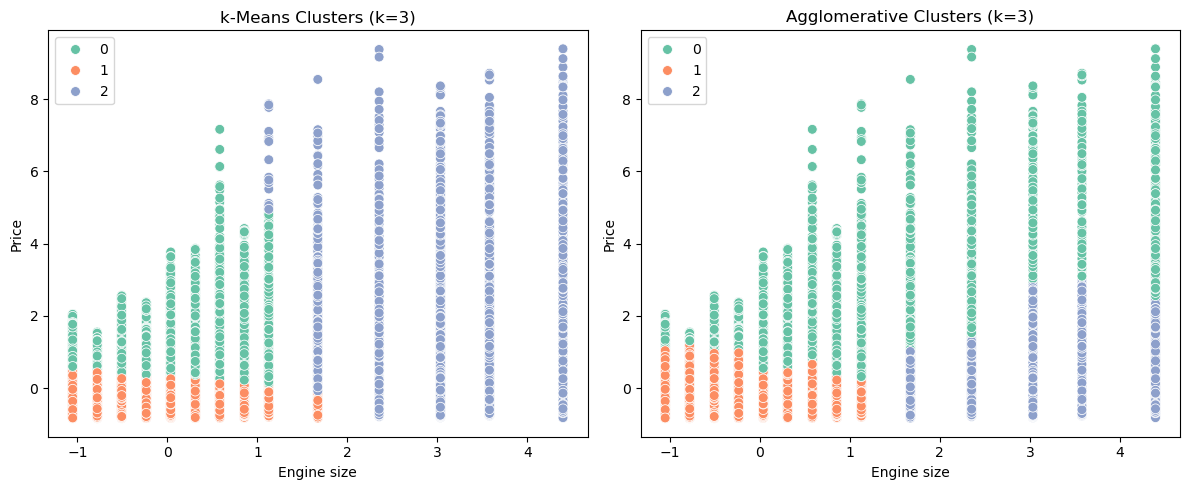

✅ Agglomerative Clustering produces better clustering (Silhouette: 0.562)


In [104]:
# -----------------------------
# Compare k-Means vs Agglomerative Clustering 🔍
# -----------------------------
from sklearn.cluster import AgglomerativeClustering

# Choose the best feature combination from previous step
best_features = ['Engine size', 'Price']  # example: pick highest silhouette from Step 7
X = car_sales[best_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- k-Means ---
best_k = 3  # replace with optimal k from Step 7 for this feature set
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"k-Means Silhouette Score: {kmeans_silhouette:.3f}")

# --- Agglomerative Clustering ---
agglo = AgglomerativeClustering(n_clusters=best_k)
agglo_labels = agglo.fit_predict(X_scaled)
agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
print(f"Agglomerative Clustering Silhouette Score: {agglo_silhouette:.3f}")

# --- Visual comparison ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=kmeans_labels, palette='Set2', s=50)
plt.title(f'k-Means Clusters (k={best_k})')
plt.xlabel(best_features[0])
plt.ylabel(best_features[1])

plt.subplot(1,2,2)
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=agglo_labels, palette='Set2', s=50)
plt.title(f'Agglomerative Clusters (k={best_k})')
plt.xlabel(best_features[0])
plt.ylabel(best_features[1])

plt.tight_layout()
plt.savefig(file_path / "final.png")
plt.show()

# --- Conclusion ---
if kmeans_silhouette > agglo_silhouette:
    print(f"✅ k-Means produces better clustering (Silhouette: {kmeans_silhouette:.3f})")
else:
    print(f"✅ Agglomerative Clustering produces better clustering (Silhouette: {agglo_silhouette:.3f})")


# Exercise 2 — Image Recognition: MNIST CNN

### 📂 Loading the MNIST Dataset


In [50]:
# Load the file (update path if needed)
mnist_data = np.load(file_path / 'mnist.npz')


### 🖼️ MNIST Dataset Overview

The MNIST dataset is loaded and split into training (60,000 images) and test (10,000 images) sets. Each 28×28 grayscale image is paired with a label. A few sample images are visualized with their labels to verify data integrity.


#### 📷 Function to Plot Sample Images

This function displays `n` images in a 3×3 grid along with their labels. It handles both grayscale images with or without a channel dimension and supports integer or one-hot encoded labels. The function returns the matplotlib figure object for further use or customization.


In [51]:
def plot_images(images, labels, n=9, title_prefix="Label:"):
    """
    Plot n images in a 3x3 grid with their labels and return the figure object.
    
    images : numpy array of shape (num_samples, 28, 28) or (num_samples, 28, 28, 1)
    labels : one-hot encoded or integer labels
    n      : number of images to plot (default 9)
    
    Returns:
    fig : matplotlib.figure.Figure
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(3, 3, figsize=(6,6))
    axes = axes.flatten()
    
    for i in range(n):
        # reshape if single channel
        img = images[i].reshape(28,28) if images[i].ndim == 3 or images[i].shape[-1]==1 else images[i]
        axes[i].imshow(img, cmap='gray')
        
        # convert one-hot to integer if needed
        lbl = labels[i].argmax() if labels[i].ndim > 0 and labels[i].size > 1 else labels[i]
        axes[i].set_title(f"{title_prefix} {lbl}")
        axes[i].axis('off')
    
    plt.tight_layout()
    return fig


Training set: (60000, 28, 28) (60000,)
Test set: (10000, 28, 28) (10000,)


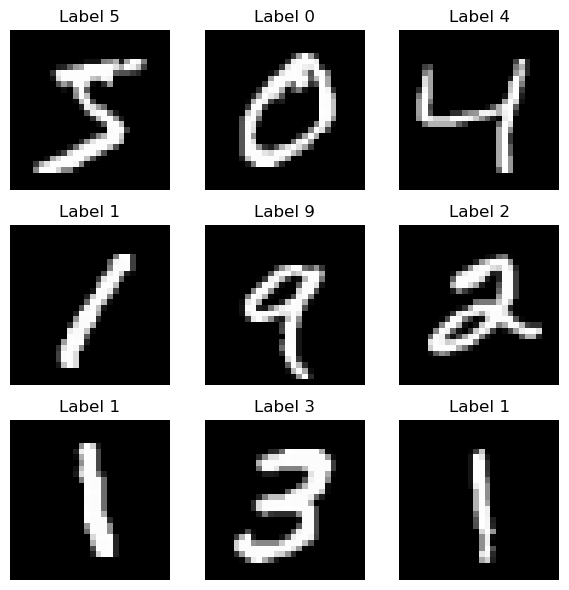

In [52]:
# Extract arrays
x_train = mnist_data['x_train']   
y_train = mnist_data['y_train']   
x_test  = mnist_data['x_test']    
y_test  = mnist_data['y_test']    

# Check shapes
print("Training set:", x_train.shape, y_train.shape)
print("Test set:", x_test.shape, y_test.shape)

# Inspect a few samples using the reusable function
fig = plot_images(x_train, y_train, n=9, title_prefix="Label")

# Save the figure
fig.savefig(file_path / "Ex2. Data Overview.png", bbox_inches='tight')

# Display the figure
display(fig)

### 🧮 Normalizing and Reshaping MNIST Data

The pixel values of the images are normalized to the range [0, 1] to improve training stability. The images are then reshaped to include a channel dimension `(28, 28) → (28, 28, 1)` to make them compatible with convolutional neural networks (CNNs). The shapes of the training and test sets are checked to confirm the transformation.


In [53]:
# Normalize pixel values to [0,1] and reshape for CNN
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# CNNs expect a channel dimension: (28,28) -> (28,28,1)
x_train = np.expand_dims(x_train, -1)  
x_test  = np.expand_dims(x_test, -1)   

# Check shapes to verify
print("After normalization and reshaping:")
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)


After normalization and reshaping:
x_train: (60000, 28, 28, 1)
x_test : (10000, 28, 28, 1)


### 🎯 One-Hot Encoding Labels

The target labels are converted to one-hot encoded vectors, creating a binary matrix representation for the 10 digit classes. This format is required for categorical classification in neural networks. The shapes of the resulting arrays are verified to ensure correctness.


In [54]:
# One-hot encode labels
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)

# Check shapes
print("After one-hot encoding labels:")
print("y_train one-hot:", y_train_cat.shape)  
print("y_test one-hot :", y_test_cat.shape)   


After one-hot encoding labels:
y_train one-hot: (60000, 10)
y_test one-hot : (10000, 10)


### 🔄 Data Augmentation for CNN Training

The training images are expanded to include a channel dimension and augmented using `ImageDataGenerator`. Augmentation includes small random rotations and shifts to improve model generalization. A sample batch of augmented images is generated, visualized using the reusable plotting function, and saved for reference.


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def visualize_augmentation(x, y, n_samples=9, rotation=8, width_shift=0.08, height_shift=0.08, title_prefix="Augmented"):
    """
    Generate and plot a batch of augmented images.

    x           : input images, shape (num_samples, 28,28,1)
    y           : labels (one-hot or integer)
    n_samples   : number of images to display
    rotation    : max rotation in degrees
    width_shift : horizontal shift fraction
    height_shift: vertical shift fraction
    title_prefix: title for each image
    """
    datagen = ImageDataGenerator(
        rotation_range=rotation,
        width_shift_range=width_shift,
        height_shift_range=height_shift
    )
    # Fit generator (optional for MNIST)
    datagen.fit(x)
    
    # Generate a batch
    sample_iter = datagen.flow(x[:n_samples], y[:n_samples], batch_size=n_samples)
    x_batch, y_batch = next(sample_iter)
    
    # Use the reusable plot_images function
    fig = plot_images(x_batch, y_batch, n=n_samples, title_prefix=title_prefix)
    return fig, datagen


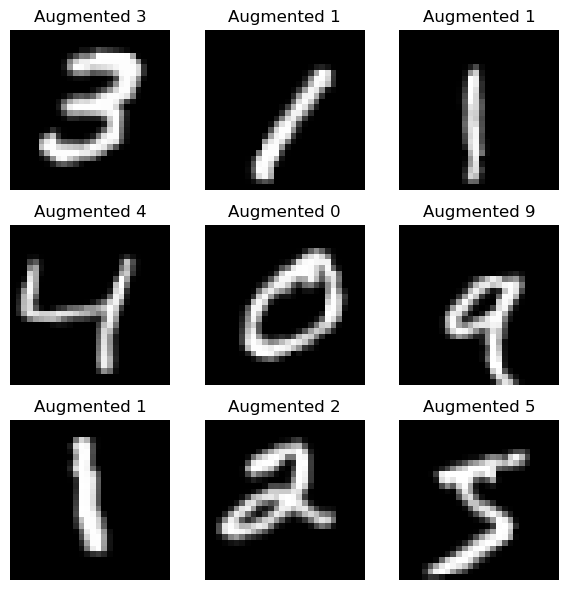

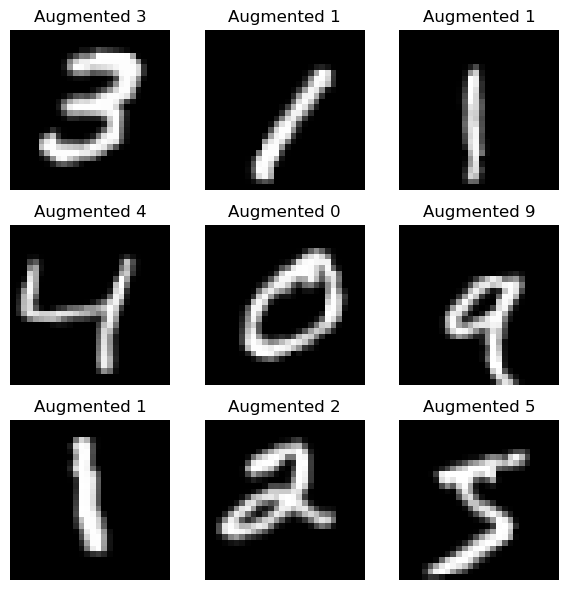

In [10]:
# Ensure x_train has shape (samples, height, width, channels)
# Ensure input is 4D (N, 28, 28, 1)
if x_train.ndim == 3:   # (60000, 28, 28)
    x_train_cnn = np.expand_dims(x_train, -1)
elif x_train.ndim == 4: # already (60000, 28, 28, 1)
    x_train_cnn = x_train
else:
    raise ValueError(f"Unexpected shape: {x_train.shape}")


# Data Augmentation & Visualization using reusable function
fig, datagen = visualize_augmentation(
    x_train_cnn, 
    y_train_cat, 
    n_samples=9, 
    rotation=8, 
    width_shift=0.08, 
    height_shift=0.08, 
    title_prefix="Augmented"
)

# Save and display figure
fig.savefig(file_path / "Ex2. Augmented Samples.png", bbox_inches='tight')
from IPython.display import display
display(fig)


### 🔀 Splitting Training Data for Validation

The normalized and reshaped training set is split to reserve 10% for validation. Stratified sampling ensures that class distribution remains balanced between the training and validation sets. The shapes of the resulting training and validation sets are checked to confirm the split.


In [11]:
from sklearn.model_selection import train_test_split

# x_train_cnn is your normalized and reshaped training data (60000, 28, 28, 1)
# y_train_cat is the one-hot encoded labels

# Split 10% of training data for validation
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_cnn, y_train_cat,
    test_size=0.10,        
    stratify=y_train,      
    random_state=42
)

# Check shapes
print("Training set after split:", x_train_final.shape, y_train_final.shape)
print("Validation set:", x_val.shape, y_val.shape)


Training set after split: (54000, 28, 28, 1) (54000, 10)
Validation set: (6000, 28, 28, 1) (6000, 10)


### 🤖 CNN Model Architecture
The CNN consists of two convolutional blocks, each with a `Conv2D` layer (ReLU), `BatchNormalization`, `MaxPooling2D`, and `Dropout` for regularization. The output is flattened and passed through a dense layer (128 units, ReLU) with dropout, followed by a `softmax` output layer for 10-class digit classification.  

**Justification:**  
- Convolutions extract spatial features.  
- Batch normalization stabilizes training.  
- Max pooling reduces dimensions.  
- Dropout prevents overfitting.  
- Dense layer combines features before classification.


In [24]:
# Import necessary layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Function to build the CNN model
def build_cnn():
    """
    Builds a Convolutional Neural Network (CNN) for MNIST digit classification.

    Architecture:
    - Conv2D (32 filters, 3x3 kernel) + ReLU + BatchNorm + MaxPooling (2x2) + Dropout (0.25)
    - Conv2D (64 filters, 3x3 kernel) + ReLU + BatchNorm + MaxPooling (2x2) + Dropout (0.25)
    - Flatten
    - Dense (128 units, ReLU) + Dropout (0.5)
    - Dense (10 units, Softmax) for output classes (digits 0-9)

    Returns:
        model (tf.keras.Sequential): Compiled CNN model ready for training.
    """
    model = Sequential([
        # First convolutional block
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),  # 32 filters, 3x3 kernel
        BatchNormalization(),                                          
        MaxPooling2D((2,2)),                                           
        Dropout(0.25),                                                 

        # Second convolutional block
        Conv2D(64, (3,3), activation='relu'),                           # 64 filters, 3x3 kernel
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        # Fully connected layers
        Flatten(),                                                     
        Dense(128, activation='relu'),                                 
        Dropout(0.5),
        Dense(10, activation='softmax')                                 # Output layer for 10 classes
    ])
    return model


### 🖥️Model Training and Performance
The model was trained for 10 epochs with a batch size of 64 and a validation split of 20%. The training and validation accuracy and loss were monitored to evaluate convergence and check for overfitting.  

- Accuracy and loss curves indicate how well the model learns over epochs.  
- Small gaps between training and validation curves suggest minimal overfitting.


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.8912 - loss: 0.3589 - val_accuracy: 0.9821 - val_loss: 0.0606
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9615 - loss: 0.1323 - val_accuracy: 0.9847 - val_loss: 0.0535
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9692 - loss: 0.1054 - val_accuracy: 0.9870 - val_loss: 0.0456
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9733 - loss: 0.0888 - val_accuracy: 0.9866 - val_loss: 0.0487
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9772 - loss: 0.0790 - val_accuracy: 0.9889 - val_loss: 0.0467
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9780 - loss: 0.0733 - val_accuracy: 0.9898 - val_loss: 0.0404
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9800 - loss: 0.0646 - val_accuracy: 0.9876 - val_loss: 0.0488
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9825 - loss: 0.0602 - 

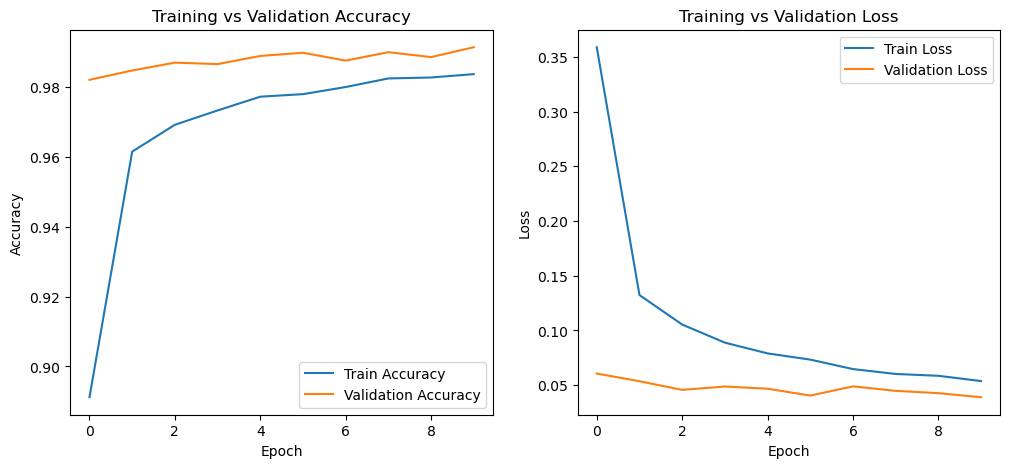

In [17]:
# Compile the CNN model
model = build_cnn()                        # Build model from Code Block 2
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model with validation split
history = model.fit(
    x_train, y_train_cat, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.2
)


plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


# Save figure as PNG
plt.savefig(file_path / "training_validation_curves.png", dpi=300, bbox_inches='tight')
plt.show()


**🧪 Hyperparameter Tuning and Performance**  
A grid search was conducted to examine the effects of batch size, dropout rate, and number of filters on validation accuracy. Each configuration was trained for 5 epochs to quickly assess performance.

- Validation accuracy was highest for dropout = 0.5 and filters = 64.  
- The hyperparameter comparison plot illustrates which settings improve performance.  
- The plot is saved as `hyperparameter_comparison.png`.


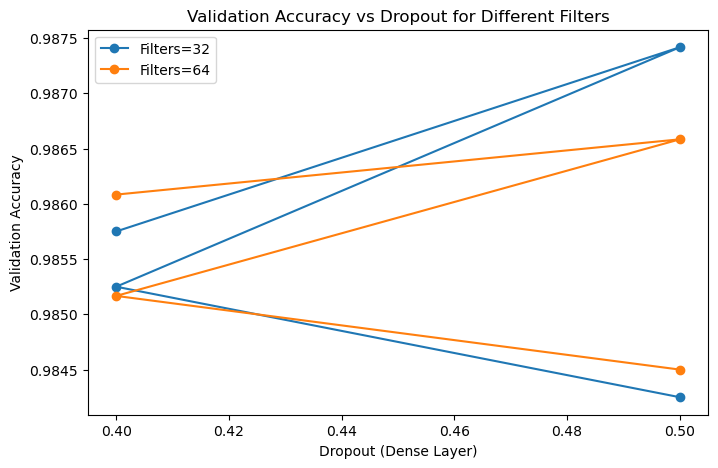

In [19]:
# -------------------------------
# Hyperparameter Tuning & Visualization
# -------------------------------

import itertools

# Define hyperparameter grid
param_grid = {
    'batch_size': [32, 64],
    'dropout_dense': [0.4, 0.5],
    'filters_block1': [32, 64]
}

results = []

# Manual grid search over hyperparameters
for batch_size, dropout_dense, filters_block1 in itertools.product(
        param_grid['batch_size'], 
        param_grid['dropout_dense'], 
        param_grid['filters_block1']):
    
    # Build simple CNN with current hyperparameters
    model = Sequential([
        Conv2D(filters_block1, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_dense),
        Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train for few epochs to check validation performance
    hist = model.fit(x_train, y_train_cat, epochs=5, batch_size=batch_size, validation_split=0.2, verbose=0)
    
    val_acc = hist.history['val_accuracy'][-1]
    results.append((batch_size, dropout_dense, filters_block1, val_acc))

# Convert results to numpy array for plotting
results = np.array(results)

# Plot hyperparameter comparison
plt.figure(figsize=(8,5))
for filters in np.unique(results[:,2]):
    subset = results[results[:,2]==filters]
    plt.plot(subset[:,1], subset[:,3], marker='o', label=f'Filters={int(filters)}')
plt.title('Validation Accuracy vs Dropout for Different Filters')
plt.xlabel('Dropout (Dense Layer)')
plt.ylabel('Validation Accuracy')
plt.legend()

# Save figure
plt.savefig(file_path / "hyperparameter_comparison.png", dpi=300, bbox_inches='tight')

plt.show()


**🎯 Final Model Evaluation**  
The final CNN model, trained with the best hyperparameters, was evaluated on the MNIST test set.

- **Test Accuracy:** Indicates the proportion of correctly classified digits.  
- **Test Loss:** Measures the prediction error on unseen data.  
- Training on the full dataset ensures the model has learned from all available examples.  
- The results demonstrate the model’s generalization performance.


In [21]:
# -------------------------------
# Final Model Evaluation
# -------------------------------

# Build the final CNN model (use best hyperparameters from tuning)
final_model = build_cnn()  

# Compile the model
final_model.compile(optimizer='adam', 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])

# Train the model on full training data
final_history = final_model.fit(
    x_train, y_train_cat, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.2
)

# Evaluate the model on the test set
test_loss, test_acc = final_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8893 - loss: 0.3685 - val_accuracy: 0.9770 - val_loss: 0.0782
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9594 - loss: 0.1396 - val_accuracy: 0.9849 - val_loss: 0.0550
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9691 - loss: 0.1064 - val_accuracy: 0.9864 - val_loss: 0.0500
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9741 - loss: 0.0889 - val_accuracy: 0.9884 - val_loss: 0.0461
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9765 - loss: 0.0791 - val_accuracy: 0.9888 - val_loss: 0.0451
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9785 - loss: 0.0737 - val_accuracy: 0.9896 - val_loss: 0.0390
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9814 - loss: 0.0667 - val_accuracy: 0.9892 - val_loss: 0.0421
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9828 - loss: 0.0594 - 

### 📊 Confusion Matrix of Final Model
The confusion matrix shows how well the final CNN classifies each digit in the MNIST test set.  

- Diagonal elements represent correct predictions; off-diagonal elements indicate misclassifications.  
- Most digits are classified correctly, with only a few confusions between similar digits (e.g., 4 and 9).  
- The confusion matrix plot is saved as `confusion_matrix.png`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


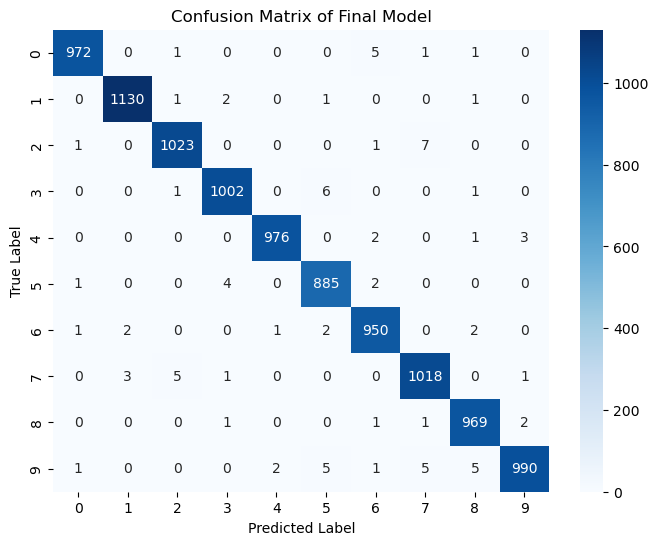

In [22]:
# -------------------------------
# Confusion Matrix Generation & Plot
# -------------------------------

from sklearn.metrics import confusion_matrix

# Predict classes on test data
y_pred = final_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)  # Convert one-hot back to labels

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix of Final Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Save figure
plt.savefig(file_path / "confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()
